In [ ]:
pip install tensorflow

            Date        Open        High         Low       Close   Adj Close  \
0     2019-02-28   21.261333   21.333332   20.720667   21.325333   21.325333   
1     2019-03-01   20.462667   20.475332   19.459999   19.652666   19.652666   
2     2019-03-04   19.874666   19.933332   18.851999   19.024000   19.024000   
3     2019-03-05   18.799999   18.933332   18.006666   18.436001   18.436001   
4     2019-03-06   18.431999   18.767332   18.292667   18.416000   18.416000   
...          ...         ...         ...         ...         ...         ...   
1254  2024-02-22  194.000000  198.320007  191.360001  197.410004  197.410004   
1255  2024-02-23  195.309998  197.570007  191.500000  191.970001  191.970001   
1256  2024-02-26  192.289993  201.779999  192.000000  199.399994  199.399994   
1257  2024-02-27  204.039993  205.600006  198.259995  199.729996  199.729996   
1258  2024-02-28  200.419998  205.300003  198.440002  202.039993  202.039993   

         Volume  
0     157810500  
1  

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.1045
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0166
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0122
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0101
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0100
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0118
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0115
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0103
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0099
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0107
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0100
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0075
Epoch 13/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0089
Epoch 14/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0095
Epoch 15/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.

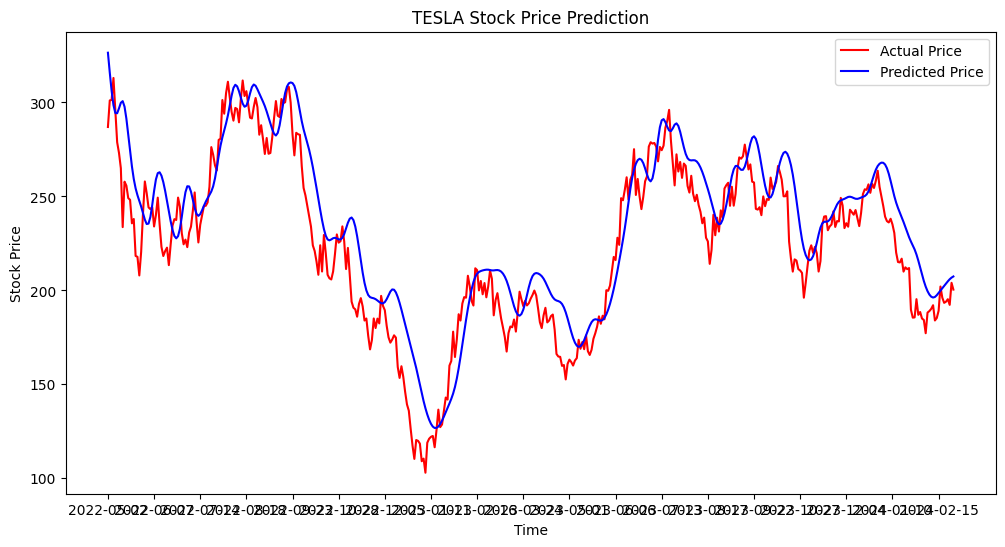

In [ ]:
# Importing Libraries
# Numpy and Pandas
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
# Pre-Processing Module
from sklearn.preprocessing import MinMaxScaler

# Keras Modules
from keras.models import Sequential
from keras.layers import *
from keras.layers import LSTM, Dropout

# Importing dataset
tesla = pd.read_csv("/content/Tesla.csv")

# Printing dataset
print(tesla)

# Data Splitting
training = tesla.iloc[:800, 1:2].values
testing = tesla.iloc[800:, 1:2].values

# Data Normalization
mm_scale = MinMaxScaler(feature_range=(0, 1))
training_scaled = mm_scale.fit_transform(training)

# Data structure with 60 time steps and 1 output
x_train = []
y_train = []
for i in range(60, 800):
    x_train.append(training_scaled[i-60:i, 0])
    y_train.append(training_scaled[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Model Architecture
model = Sequential()

# Building Model
model.add(LSTM(units=25, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units= 25, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units= 25, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units= 25, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=25, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=25))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fitting values to model
model.fit(x_train, y_train, epochs=100, batch_size=32)

# Preparing Test Data
train_data = tesla.iloc[:800, 1:2]
test_data = tesla.iloc[800:, 1:2]
total_data = pd.concat((train_data, test_data), axis=0)
inputs = total_data[len(total_data) - len(test_data) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = mm_scale.transform(inputs)

x_test = []
for i in range(60, 519):
    x_test.append(inputs[i-60:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Prediction
stock_price_predicted = model.predict(x_test)
stock_price_predicted = mm_scale.inverse_transform(stock_price_predicted)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(tesla.loc[800:, "Date"], test_data.values, color="red", label="Actual Price")
plt.plot(tesla.loc[800:, "Date"], stock_price_predicted, color="blue", label="Predicted Price")
plt.xticks(np.arange(0, 459, 25))
plt.title('TESLA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful